# The nonlinear policy problem—and what remains unsolved

The local model is informative only near one interior steady state. Farther away, public wealth can approach a financing boundary, the tax adjustment margin can change sharply, and the desired risky position can encounter constraints. The richer object is therefore a nonlinear Ramsey problem in five states.

The notebook writes that problem in reader-facing order and then shows the only completed numerical stage: a pre-solve screen of primitives on an illustrative state box. No value function or nonlinear policy has yet been computed.

## States, choices, and inherited quantities

The state is

$$
S=(z,x,k,n,\tau),
\qquad
k=\log K,
\qquad
n=\frac{N}{K}.
$$

Here $z$ and $x$ are productivity and automation states, $K$ is private capital, $N$ is public net worth, and $\tau$ is the capital-tax rate. The normalized controls are worker consumption $\chi=c/K$, the risky public holding $\theta=s/K$, and tax speed $\nu=\dot\tau$.

The two shocks follow mean-reverting diffusions. Capital, public net worth, and the tax rate are inherited states. The government chooses current consumption, portfolio exposure, and how quickly to move the tax rate. Worker welfare is the objective, domestic capital remains privately owned, and the risky instrument is an external claim priced under a small-open, price-taking closure in which foreign investors absorb residual positions.

## The Bellman equation

Let $v(S)$ denote normalized continuation value. The operator $\mathcal L^{z,x}$ describes the two exogenous diffusions, $g$ is capital growth, $f$ is the net public flow per unit of capital, and $y$ is output per unit of capital. The claim's variance is $\beta_I=\|\lambda_I\|^2>0$. Its covariance with changes in the marginal value of public wealth is

$$
D_v
=
\sigma_z\lambda_I^P v_{zn}
+
\sigma_x\lambda_I^A v_{xn}.
$$

After optimizing over the three current controls, any smooth interior solution must satisfy

$$
\begin{aligned}
\rho v={}&-\log v_n-1+\mathcal L^{z,x}v
+g\left(\frac1\rho+v_k\right)
+[(r_I-g)n+f]v_n\\
&+\frac{\kappa_\tau}{2y}\frac{v_\tau^2}{v_n}
-\frac{(\beta_Iv_n+D_v)^2}{2\beta_Iv_{nn}}.
\end{aligned}
$$

The corresponding interior controls are

$$
\chi=\frac1{v_n},
\qquad
\nu=\frac{\kappa_\tau}{y}\frac{v_\tau}{v_n},
\qquad
\theta=-\frac{\beta_Iv_n+D_v}{\beta_Iv_{nn}}.
$$

These formulas reveal the economic roles of the derivatives. The marginal value $v_n$ sets consumption; $v_\tau$ measures the continuation value of moving the tax rate; and the portfolio numerator combines compensated return demand, $\beta_Iv_n$, with the fiscal hedge, $D_v$. For these quotients to describe finite interior maxima, the candidate must satisfy $v_n>0$ and $v_{nn}<0$.

This is an HJB characterization. It does not prove that a solution exists, that the candidate is globally optimal, or that it respects boundaries and transversality.

## The implemented first step: screen the proposed domain

Before attempting a five-dimensional solve, the code evaluates model primitives at factorial-grid points, seeded interior points, and dense one-dimensional automation scans. The screen asks whether formulas remain finite and whether the sampled points stay on the intended specialization branch. It does not evaluate the HJB because there is not yet a value candidate.

In [1]:
import json
from pathlib import Path
from IPython.display import Markdown, display

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs004_presolve_snapshot.json"),
        Path("data/cs004_presolve_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))
design = snapshot["design_summary"]

lines = [
    "| Sampled-domain check | Result |",
    "|---|---:|",
    f"| points evaluated | {design['total']:,} |",
    f"| nonfinite primitive evaluations | {snapshot['nonfinite_point_count']} |",
    f"| nonpositive specialization or claim-variance margins | "
    f"{sum(snapshot['margin_violations'].values())} |",
    f"| sampled automation, output, or wage sign violations | "
    f"{sum(snapshot['sign_violations'].values())} |",
]
display(Markdown("\n".join(lines)))

| Sampled-domain check | Result |
|---|---:|
| points evaluated | 2,986 |
| nonfinite primitive evaluations | 0 |
| nonpositive specialization or claim-variance margins | 0 |
| sampled automation, output, or wage sign violations | 0 |

## How far the sampled points are from two boundaries

The left panel reports the smallest specialization margins found in the central and buffer samples. Positive bars mean that every sampled point remained on the smooth specialization branch. The right panel applies a different test: whether normalized public net worth exceeds a declared reference floor by at least $\eta_{\mathrm{sol}}=0.01$. That floor is a numerical reference, not a theorem about the government's true borrowing capacity.

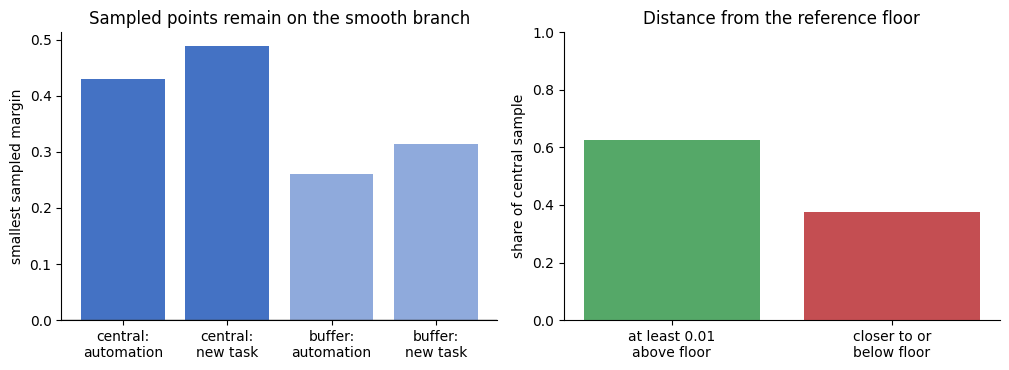

The dense buffer scan gives a claim-variance term between **0.0013505** and **0.0017008**. The declared reference floor is n_ref(tau) = -0.12 * tau * (1 - tau).

In [2]:
import matplotlib.pyplot as plt

minima = snapshot["sampled_minima"]
reference = snapshot["reference_floor"]
labels = ["central:\nautomation", "central:\nnew task", "buffer:\nautomation", "buffer:\nnew task"]
values = [
    minima["central_specialisation_automation"],
    minima["central_specialisation_new_task"],
    minima["buffer_specialisation_automation"],
    minima["buffer_specialisation_new_task"],
]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.8))
axes[0].bar(labels, values, color=["#4472C4", "#4472C4", "#8FAADC", "#8FAADC"])
axes[0].axhline(0, color="0.25", linewidth=1)
axes[0].set_ylabel("smallest sampled margin")
axes[0].set_title("Sampled points remain on the smooth branch")

fraction = reference["central_fraction_meeting"]
axes[1].bar(
    ["at least 0.01\nabove floor", "closer to or\nbelow floor"],
    [fraction, 1 - fraction],
    color=["#55A868", "#C44E52"],
)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("share of central sample")
axes[1].set_title("Distance from the reference floor")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

display(
    Markdown(
        f"The dense buffer scan gives a claim-variance term between "
        f"**{minima['buffer_beta_I_dense_min']:.7f}** and "
        f"**{minima['buffer_beta_I_dense_max']:.7f}**. "
        f"The declared reference floor is {reference['formula']}."
    )
)

## What a genuine nonlinear result would still have to show

The sample supports one narrow conclusion: the chosen box contains many finite primitive evaluations with positive sampled smooth-branch margins. Only 62.6 percent of the central points sit at least 0.01 above the declared reference floor, so the future solver must treat that region carefully.

A reported nonlinear policy would require more than a small training loss. It would need:

1. a value candidate with independently coded optimized and unoptimized HJB residuals;
2. recovered controls that satisfy curvature, bounds, and feasibility throughout the reported region;
3. ordinary and boundary-stress paths that remain in the intended domain;
4. a terminal, transversality, or boundary argument appropriate to the selected solution; and
5. a verification step connecting the candidate and its controls to the Ramsey value.

Global existence and uniqueness need not be claimed for an informative numerical policy on a stated domain. But an HJB and its first-order conditions alone are not a proof of optimality.

## Reproduce and trace

- Source: [tai-public-finance-ramsey-pde at commit b287168](https://github.com/Nathan-Barnard/tai-public-finance-ramsey-pde/tree/b287168c8593a5110ca52eb8bc19890f76fbb85b)
- Screen implementation: 8815c82e980b87a892bbb30860e9bb83acdf87ed
- Run: RUN-20260901T204946Z-CS004-2713208-01; computation CP004; draft specification CS004; HJB characterization R06
- Frozen export: notebooks/data/cs004_presolve_snapshot.json
- Environment: Python 3.13.5, NumPy 2.5.2, SciPy 1.18.1, FP64 CPU; upstream uv.lock

The run record names an older commit than the final frozen screen implementation. The sample is therefore retained as an exploratory diagnostic, not accepted nonlinear evidence. Re-running the documented entrypoint reproduces the pre-solve screen only; the frozen source contains no PDE training or solution command.